# Training a U-net on CM0 data, testing on CM0 holdout + artificial misalignment + transfer to CM3

This notebook shows how to use the codebase provided to train a U-net on CM0 data (validation set), test it on the CM0 holdout set,
test it on artificially induced misaligned data, and finally transfer it to CM3.

The CM3 transfer requires cutting out the active regions between scalar multiplications, because the U-net has never seen anything like them
in CM0 training. 

In [1]:
import model_library as ml
import learning_rates as lr

import numpy as np

from keras.callbacks import ModelCheckpoint
from keras import backend as K

from matplotlib import pyplot as plt

from experiments import train_unet_ctc

from processing import resize_data

import Levenshtein

2026-02-12 15:03:21.872556: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 15:03:21.934166: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aron/.pyenv/versions/3.10.12/envs/testenv_kiska/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at le

In [ ]:
data = np.load('../data/cm0/ecc_cm0_1024traces_2000pts.npz')

data_full_test = np.load('../data/cm0/cm0_2000.npz')

In [3]:
list(data)

['X_train',
 'Y_train',
 'Y_bits_train',
 'X_test',
 'Y_test',
 'Y_bits_test',
 'X_holdout',
 'Y_holdout',
 'Y_bits_holdout']

In [ ]:
X_train,Y_train = data['X_train'],data['Y_bits_train']
X_test,Y_test = data['X_test'],data['Y_bits_test']
X_holdout,Y_holdout = data['X_holdout'],data['Y_bits_holdout']

# we resize to 1600 points to match the resolution of the original experiments with transfer to CM3, which was trained on CM1 resampled to 5000 points

X_train = resize_data(X_train, 1600)
X_test = resize_data(X_test, 1600)
X_holdout = resize_data(X_holdout, 1600)

print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)
print(X_holdout.shape,Y_holdout.shape)

X_test_full, Y_test_full = data_full_test['X'], data_full_test['Y']

X_test_full = resize_data(X_test_full, 1600)
X_test_full.shape

print(np.mean(np.square(X_test_full[1] - X_test[1])))
print(np.mean(np.square(X_test_full[171] - X_test[171])))
print(Y_test_full[0])
print(Y_test[0])



100%|██████████| 1024/1024 [00:00<00:00, 36809.48it/s]


(1024, 1600) (1024, 256)
(1024, 1600) (1024, 256)
(1024, 1600) (1024, 256)


100%|██████████| 8192/8192 [00:00<00:00, 36653.75it/s]

5.92117400886419e-17
3.879499298493439e-17
[1 1 0 0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0
 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 0 1 0 1 1 1 0 0 0 1
 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 1
 0 0 0 1 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 1 0
 0 1 1 1 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0
 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1 0
 0 1 0 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1 1 1 0 0 1 0 1 1 0 0]
[1 1 0 0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0
 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 0 1 0 1 1 1 0 0 0 1
 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 1
 0 0 0 1 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 1 0
 0 1 1 1 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0
 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 1 0 1 1

In [5]:
check = ModelCheckpoint('unet_cm0_1600_fresh.keras', save_best_only=True, save_weights_only=True)

In [6]:
seq_length = X_test_full.shape[1]  # 1600
num_features = Y_test_full.shape[1]  # 256

unet, history = train_unet_ctc(
    X_test_full, Y_test_full,
    seq_length=seq_length,
    num_features=num_features,
    depth=4,
    n_filters=64,
    epochs=21,
    batch_size=32,
    validation_split=0.1,
    learning_rate=1e-3,
    min_learning_rate=1e-6,
    learning_rate_cycle=20,
    output_channels=3,
    check=check
)

2026-02-12 15:03:24.154143: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-12 15:03:24.170427: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-12 15:03:24.170520: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-12 15:03:24.170803: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuil

Epoch 1/21
Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


2026-02-12 15:03:30.638208: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8904
2026-02-12 15:03:31.014796: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x565b3fce9540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-12 15:03:31.014819: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2026-02-12 15:03:31.018585: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-12 15:03:31.080410: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


231/231 [==============================] - 57s 207ms/step - loss: 478.8985 - val_loss: 466.9505 - lr: 1.0000e-06
Epoch 2/21
231/231 [==============================] - 46s 197ms/step - loss: 198.8454 - val_loss: 286.5594 - lr: 1.0090e-04
Epoch 3/21
231/231 [==============================] - 45s 195ms/step - loss: 152.6958 - val_loss: 193.9727 - lr: 2.0080e-04
Epoch 4/21
231/231 [==============================] - 45s 195ms/step - loss: 55.8514 - val_loss: 162.4774 - lr: 3.0070e-04
Epoch 5/21
231/231 [==============================] - 47s 202ms/step - loss: 17.1139 - val_loss: 152.1029 - lr: 4.0060e-04
Epoch 6/21
231/231 [==============================] - 46s 199ms/step - loss: 10.8310 - val_loss: 175.3032 - lr: 5.0050e-04
Epoch 7/21
231/231 [==============================] - 46s 198ms/step - loss: 7.5086 - val_loss: 165.2036 - lr: 6.0040e-04
Epoch 8/21
231/231 [==============================] - 47s 203ms/step - loss: 5.9785 - val_loss: 89.0305 - lr: 7.0030e-04
Epoch 9/21
231/231 [=======

Text(0, 0.5, 'Loss')

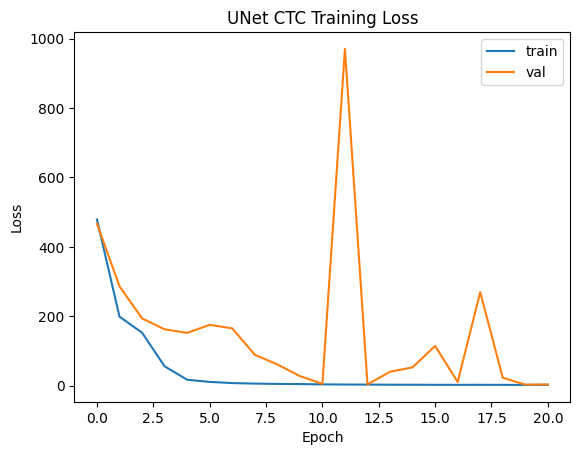

In [7]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.title('UNet CTC Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [17]:
def binary_array_to_string(arr):
    """Convert a binary array to a string of 0s and 1s."""
    return ''.join(map(str, arr.astype(int)))

def evaluate_unet_ctc(model, X, Y, seq_length, num_features, batch_size=32, label=""):
    """
    Evaluate a UNet model using CTC decoding and Levenshtein ratio.
    
    Returns decoded predictions, per-sample Levenshtein ratios, and per-position accuracy.
    """
    # Reshape X if needed
    X_eval = X
    if len(X_eval.shape) == 2:
        X_eval = X_eval[..., np.newaxis]
    
    # Predict
    logits = model.predict(X_eval, batch_size=batch_size)
    
    # CTC decode
    decoded, _ = K.ctc_decode(logits,
                              input_length=np.ones(logits.shape[0]) * seq_length,
                              greedy=True)
    decoded_dense = decoded[0].numpy()
    decoded_dense = decoded_dense[:, 0:num_features]
    
    # Per-position accuracy
    acc = np.mean(decoded_dense == Y, axis=0)
    
    # Levenshtein ratio per sample (1.0 = identical, 0.0 = completely different)
    lev_ratios = []
    for i in range(len(decoded_dense)):
        pred_str = binary_array_to_string(decoded_dense[i])
        true_str = binary_array_to_string(Y[i])
        ratio = Levenshtein.ratio(pred_str, true_str)
        lev_ratios.append(ratio)
    lev_ratios = np.array(lev_ratios)
    
    if label:
        print(f"--- {label} ---")
    print(f"  Mean per-position accuracy: {np.mean(acc):.4f}")
    print(f"  Levenshtein ratio - Mean: {np.mean(lev_ratios):.4f}, "
          f"Std: {np.std(lev_ratios):.4f}, "
          f"Min: {np.min(lev_ratios):.4f}, Max: {np.max(lev_ratios):.4f}")
    print(f"  Perfect matches (ratio=1.0): {100 * np.sum(lev_ratios == 1.0) / len(lev_ratios):.2f}%")
    
    return decoded_dense, lev_ratios, acc

In [18]:
# The freshly trained UNet is already in the 'unet' variable from training above.
# Evaluate the fresh model on train, test, and holdout sets.

pred_train_fresh, ratio_train_fresh, acc_train_fresh = evaluate_unet_ctc(
    unet, X_train, Y_train, seq_length, num_features, label="Fresh UNet - Train")

pred_test_fresh, ratio_test_fresh, acc_test_fresh = evaluate_unet_ctc(
    unet, X_test, Y_test, seq_length, num_features, label="Fresh UNet - Test")

pred_holdout_fresh, ratio_holdout_fresh, acc_holdout_fresh = evaluate_unet_ctc(
    unet, X_holdout, Y_holdout, seq_length, num_features, label="Fresh UNet - Holdout")

 1/32 [..............................] - ETA: 0s

32/32 [==============================] - 0s 12ms/step
--- Fresh UNet - Train ---
  Mean per-position accuracy: 0.7481
  Levenshtein ratio - Mean: 0.9941, Std: 0.0082, Min: 0.9482, Max: 1.0000
  Perfect matches (ratio=1.0): 47.85%
32/32 [==============================] - 0s 12ms/step
--- Fresh UNet - Test ---
  Mean per-position accuracy: 0.7454
  Levenshtein ratio - Mean: 0.9938, Std: 0.0084, Min: 0.9443, Max: 1.0000
  Perfect matches (ratio=1.0): 46.68%
32/32 [==============================] - 0s 12ms/step
--- Fresh UNet - Holdout ---
  Mean per-position accuracy: 0.7349
  Levenshtein ratio - Mean: 0.9935, Std: 0.0085, Min: 0.9257, Max: 1.0000
  Perfect matches (ratio=1.0): 43.16%


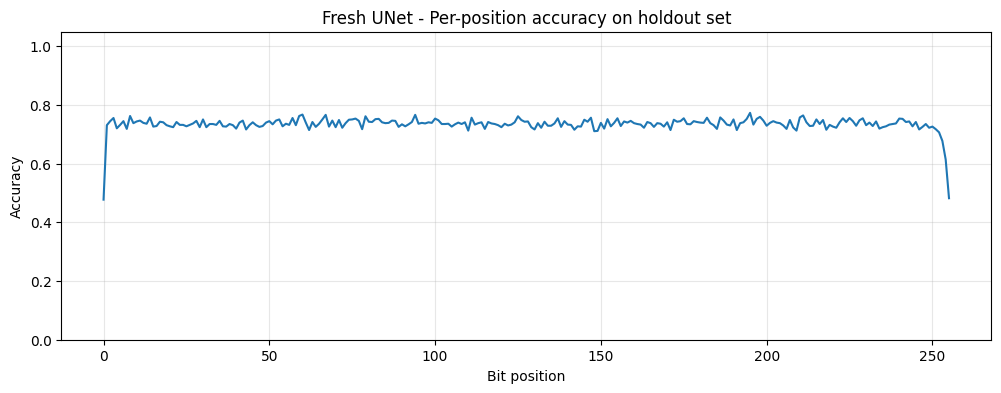

In [19]:
# Plot per-position accuracy for the fresh model on holdout
plt.figure(figsize=(12, 4))
plt.plot(acc_holdout_fresh)
plt.title('Fresh UNet - Per-position accuracy on holdout set')
plt.xlabel('Bit position')
plt.ylabel('Accuracy')
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3)

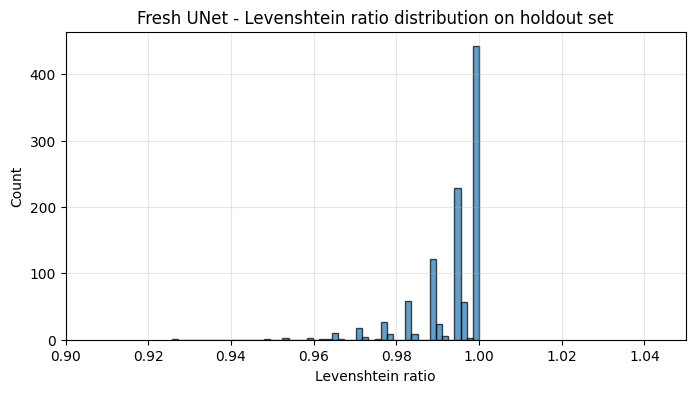

In [20]:
# Histogram of Levenshtein ratios for the fresh model on holdout
plt.figure(figsize=(8, 4))
plt.hist(ratio_holdout_fresh, bins=50, edgecolor='black', alpha=0.7)
plt.title('Fresh UNet - Levenshtein ratio distribution on holdout set')
plt.xlabel('Levenshtein ratio')
plt.ylabel('Count')
plt.xlim([0.9, 1.05])
plt.grid(True, alpha=0.3)

In [21]:
# Show some example predictions vs ground truth for the fresh model on holdout
n_examples = 5
for i in range(n_examples):
    pred_str = binary_array_to_string(pred_holdout_fresh[i])
    true_str = binary_array_to_string(Y_holdout[i])
    ratio = Levenshtein.ratio(pred_str, true_str)
    print(f"Sample {i}: Levenshtein ratio = {ratio:.4f}")
    print(f"  True: {true_str[:80]}...")
    print(f"  Pred: {pred_str[:80]}...")
    print()

Sample 0: Levenshtein ratio = 0.9903
  True: 01100110110101110100100101100010100100010000010111010100001000101000101100111110...
  Pred: 11001101101011101001001011000101001000100000101110101000010001010001011001111101...

Sample 1: Levenshtein ratio = 0.9883
  True: 00101101101111110011001100110110011111000011001111000001101100110000001111011111...
  Pred: 10110110111111001100110011011001111100001100111100000110110011000000111101111111...

Sample 2: Levenshtein ratio = 1.0000
  True: 10100000110000101111101100011101110000000111001100010000011000000001110011001111...
  Pred: 10100000110000101111101100011101110000000111001100010000011000000001110011001111...

Sample 3: Levenshtein ratio = 1.0000
  True: 10000000111010010010111110000111010011000111100011101110010011110001000001100110...
  Pred: 10000000111010010010111110000111010011000111100011101110010011110001000001100110...

Sample 4: Levenshtein ratio = 0.9767
  True: 0000100000111110110000101100010110111100010100010100011110011011101

In [22]:
# Summary: Levenshtein ratio for the fresh UNet on holdout
print("=== Fresh UNet - Holdout Set Summary ===")
print(f"Number of samples: {len(ratio_holdout_fresh)}")
print(f"Number of bits per key: {num_features}")
print()
print(f"Levenshtein ratio - Mean: {np.mean(ratio_holdout_fresh):.4f}")
print(f"Levenshtein ratio - Std:  {np.std(ratio_holdout_fresh):.4f}")
print(f"Levenshtein ratio - Min:  {np.min(ratio_holdout_fresh):.4f}")
print(f"Levenshtein ratio - Max:  {np.max(ratio_holdout_fresh):.4f}")
print()
print(f"Perfect predictions (ratio=1.0): {100 * np.sum(ratio_holdout_fresh == 1.0) / len(ratio_holdout_fresh):.2f}%")

=== Fresh UNet - Holdout Set Summary ===
Number of samples: 1024
Number of bits per key: 256

Levenshtein ratio - Mean: 0.9935
Levenshtein ratio - Std:  0.0085
Levenshtein ratio - Min:  0.9257
Levenshtein ratio - Max:  1.0000

Perfect predictions (ratio=1.0): 43.16%


In [23]:
# Summary for all sets
print("=== Fresh UNet - All Sets Levenshtein Ratio Summary ===")
for name, ratios in [("Train", ratio_train_fresh), ("Test", ratio_test_fresh), ("Holdout", ratio_holdout_fresh)]:
    print(f"\n{name}:")
    print(f"  Lev. ratio - Mean: {np.mean(ratios):.4f}, Std: {np.std(ratios):.4f}, "
          f"Min: {np.min(ratios):.4f}, Max: {np.max(ratios):.4f}")
    print(f"  Perfect:     {100 * np.sum(ratios == 1.0) / len(ratios):.2f}%")

=== Fresh UNet - All Sets Levenshtein Ratio Summary ===

Train:
  Lev. ratio - Mean: 0.9941, Std: 0.0082, Min: 0.9482, Max: 1.0000
  Perfect:     47.85%

Test:
  Lev. ratio - Mean: 0.9938, Std: 0.0084, Min: 0.9443, Max: 1.0000
  Perfect:     46.68%

Holdout:
  Lev. ratio - Mean: 0.9935, Std: 0.0085, Min: 0.9257, Max: 1.0000
  Perfect:     43.16%


In [24]:
# Custom CTC decoding that suppresses short bursts of non-blank emissions.
# Adapted from the CM3 transfer notebook (ctc_scaaml_data_test_feb_2026.ipynb).
#
# The standard greedy CTC decoder picks up all non-blank emissions, including short
# bursts that arise from non-target operations (initialisation, communication, etc.).
# These get decoded as spurious key bits that shift the alignment of the real key.
#
# Strategy: segment the per-timestep argmax sequence into "active regions" separated
# by long blank gaps (>= min_gap consecutive blanks). Then discard any active region
# whose greedy CTC decode yields fewer than min_region_symbols decoded symbols.
#
# Parameters are scaled for CM0 (1600-point traces, single 256-bit key):
#   CM3 used min_gap=100 at 17500 points  -> CM0: ~10
#   CM3 used min_region_symbols=150 for 256-bit shares -> CM0: ~50

def ctc_decode_suppress_short_bursts(predictions, min_gap=10, min_region_symbols=50,
                                      blank_idx=2, verbose=False):
    """
    Greedy CTC decoding with short-burst suppression.
    
    Parameters
    ----------
    predictions : ndarray, shape (batch, time_steps, num_classes)
        Raw softmax output from the model.
    min_gap : int
        Minimum number of consecutive blank timesteps that separates two
        independent active regions.
    min_region_symbols : int
        Minimum number of decoded symbols an active region must produce to
        be retained.  Regions producing fewer symbols are suppressed.
    blank_idx : int
        Index of the CTC blank class in the output channels.
    verbose : bool
        If True, print diagnostic information for the first trace.
        
    Returns
    -------
    decoded_list : list of 1D int arrays
        One variable-length array of decoded symbols per trace.
    region_info : list of list of tuples
        Per-trace list of (start, end, num_decoded_symbols, kept) for each
        detected active region.  Useful for diagnostics.
    """
    batch_size, time_steps, num_classes = predictions.shape
    argmax_seq = np.argmax(predictions, axis=-1)       # (batch, time_steps)
    
    all_decoded = []
    all_region_info = []
    
    for b in range(batch_size):
        seq = argmax_seq[b]
        is_nonblank = (seq != blank_idx)
        
        # ---- Segment into active regions ----
        regions = []
        in_region = False
        region_start = 0
        consecutive_blanks = 0
        
        for t in range(time_steps):
            if is_nonblank[t]:
                if not in_region:
                    region_start = t
                    in_region = True
                consecutive_blanks = 0
            else:
                consecutive_blanks += 1
                if in_region and consecutive_blanks >= min_gap:
                    region_end = t - consecutive_blanks + 1
                    regions.append((region_start, region_end))
                    in_region = False
        
        # Close final region if still open
        if in_region:
            last_nonblank = time_steps - 1
            while last_nonblank > region_start and not is_nonblank[last_nonblank]:
                last_nonblank -= 1
            regions.append((region_start, last_nonblank + 1))
        
        # ---- Decode each region with standard CTC greedy collapse ----
        decoded_bits = []
        trace_region_info = []
        
        for start, end in regions:
            region_seq = seq[start:end]
            # CTC collapse: remove consecutive duplicates, then strip blanks
            collapsed = []
            prev = None
            for val in region_seq:
                if val != prev:
                    collapsed.append(val)
                prev = val
            collapsed = [v for v in collapsed if v != blank_idx]
            
            kept = len(collapsed) >= min_region_symbols
            trace_region_info.append((start, end, len(collapsed), kept))
            
            if kept:
                decoded_bits.extend(collapsed)
        
        if verbose and b == 0:
            print(f"Trace {b}: found {len(regions)} active regions")
            for i, (s, e, n, k) in enumerate(trace_region_info):
                tag = "KEPT" if k else "SUPPRESSED"
                print(f"  Region {i}: timesteps [{s:5d}, {e:5d})  "
                      f"-> {n:4d} decoded symbols  [{tag}]")
            print(f"  Total decoded symbols after filtering: {len(decoded_bits)}")
        
        all_decoded.append(np.array(decoded_bits, dtype=np.int32))
        all_region_info.append(trace_region_info)
    
    return all_decoded, all_region_info

32/32 [==============================] - 0s 12ms/step
Raw prediction shape: (1024, 1600, 3)

DIAGNOSTIC: Active region analysis for CM0 holdout trace 0
Trace 0: found 2 active regions
  Region 0: timesteps [   22,  1580)  ->  254 decoded symbols  [KEPT]
  Region 1: timesteps [ 1598,  1600)  ->    1 decoded symbols  [SUPPRESSED]
  Total decoded symbols after filtering: 254

COMPARISON: Standard greedy CTC  vs  Short-burst-suppressed CTC
Metric                                  Standard   Suppressed      Delta
----------------------------------------------------------------------
Mean Levenshtein ratio                    0.9935       0.9938 +   0.0002
Std dev                                   0.0085       0.0054   -0.0031
Min                                       0.9257       0.9618 +   0.0361
Max                                       1.0000       1.0000 +   0.0000
Median                                    0.9942       0.9961 +   0.0019
Perfect (ratio=1.0) %                    43.1641    

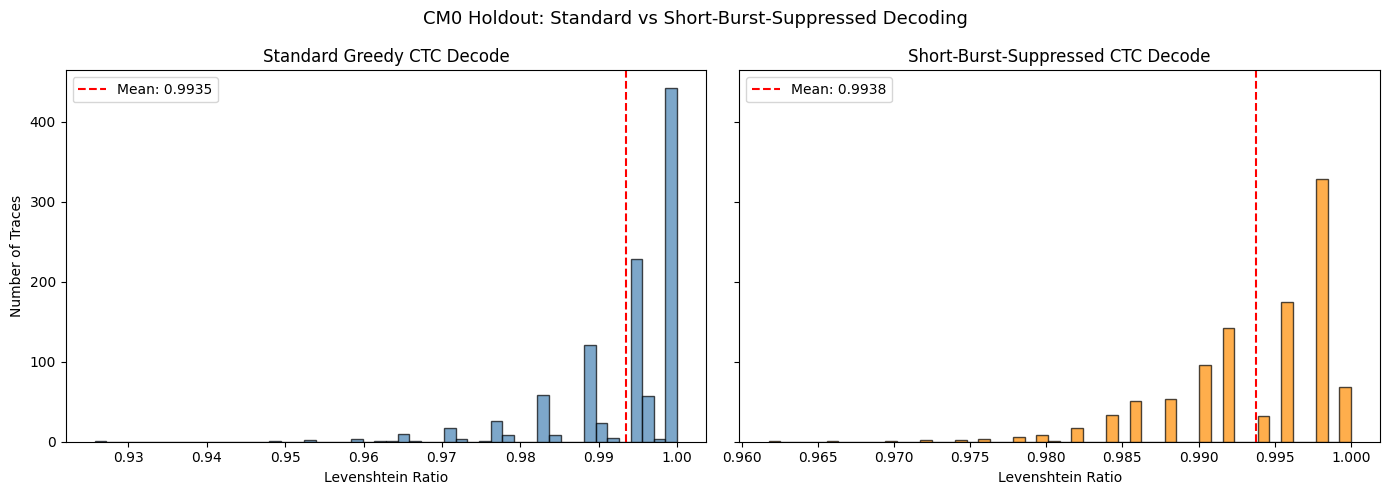

In [25]:
# Evaluate the short-burst-suppressed CTC decoder on CM0 holdout data
# and compare with the standard greedy CTC decode.

# Step 1: Get raw predictions from the model
X_holdout_eval = X_holdout if len(X_holdout.shape) == 3 else X_holdout[..., np.newaxis]
Z_holdout = unet.predict(X_holdout_eval, batch_size=32)
print(f"Raw prediction shape: {Z_holdout.shape}")

# Step 2: Run the custom decoder with diagnostics on trace 0
print("\n" + "=" * 70)
print("DIAGNOSTIC: Active region analysis for CM0 holdout trace 0")
print("=" * 70)
decoded_custom, region_info = ctc_decode_suppress_short_bursts(
    Z_holdout, min_gap=10, min_region_symbols=50, blank_idx=2, verbose=True
)

# Step 3: Compute Levenshtein ratios for both decoders
ratio_custom = []
for i in range(len(decoded_custom)):
    pred = decoded_custom[i]
    # Truncate or pad to num_features bits for comparison
    if len(pred) >= num_features:
        pred = pred[:num_features]
    pred_str = binary_array_to_string(pred)
    true_str = binary_array_to_string(Y_holdout[i])
    ratio_custom.append(Levenshtein.ratio(pred_str, true_str))
ratio_custom = np.array(ratio_custom)

# Step 4: Side-by-side comparison
print("\n" + "=" * 70)
print("COMPARISON: Standard greedy CTC  vs  Short-burst-suppressed CTC")
print("=" * 70)
print(f"{'Metric':<35s} {'Standard':>12s} {'Suppressed':>12s} {'Delta':>10s}")
print("-" * 70)

metrics = [
    ("Mean Levenshtein ratio",  np.mean(ratio_holdout_fresh),  np.mean(ratio_custom)),
    ("Std dev",                 np.std(ratio_holdout_fresh),   np.std(ratio_custom)),
    ("Min",                     np.min(ratio_holdout_fresh),   np.min(ratio_custom)),
    ("Max",                     np.max(ratio_holdout_fresh),   np.max(ratio_custom)),
    ("Median",                  np.median(ratio_holdout_fresh), np.median(ratio_custom)),
    ("Perfect (ratio=1.0) %",  100*np.mean(ratio_holdout_fresh==1.0), 100*np.mean(ratio_custom==1.0)),
]

for name, old, new in metrics:
    delta = new - old
    sign = "+" if delta >= 0 else ""
    print(f"{name:<35s} {old:>12.4f} {new:>12.4f} {sign}{delta:>9.4f}")

# Step 5: Region statistics
num_regions_all   = [len(ri) for ri in region_info]
num_kept_all      = [sum(1 for _, _, _, k in ri if k) for ri in region_info]
num_suppressed_all = [sum(1 for _, _, _, k in ri if not k) for ri in region_info]
decoded_lengths   = [len(d) for d in decoded_custom]

print(f"\nRegion statistics across all {len(decoded_custom)} CM0 holdout traces:")
print(f"  Active regions per trace:    mean={np.mean(num_regions_all):.1f}, "
      f"min={np.min(num_regions_all)}, max={np.max(num_regions_all)}")
print(f"  Kept regions per trace:      mean={np.mean(num_kept_all):.1f}")
print(f"  Suppressed regions/trace:    mean={np.mean(num_suppressed_all):.1f}")
print(f"  Decoded length after filter: mean={np.mean(decoded_lengths):.1f}, "
      f"min={np.min(decoded_lengths)}, max={np.max(decoded_lengths)}")

# Step 6: Per-trace improvement
improvement = ratio_custom - ratio_holdout_fresh
print(f"\nPer-trace improvement:")
print(f"  Traces improved:  {np.sum(improvement > 0)} / {len(improvement)}")
print(f"  Traces unchanged: {np.sum(improvement == 0)} / {len(improvement)}")
print(f"  Traces worsened:  {np.sum(improvement < 0)} / {len(improvement)}")
print(f"  Mean improvement: {np.mean(improvement):+.4f}")

# Step 7: Histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(ratio_holdout_fresh, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(ratio_holdout_fresh), color='r', linestyle='--', linewidth=1.5,
                label=f'Mean: {np.mean(ratio_holdout_fresh):.4f}')
axes[0].set_xlabel('Levenshtein Ratio')
axes[0].set_ylabel('Number of Traces')
axes[0].set_title('Standard Greedy CTC Decode')
axes[0].legend()

axes[1].hist(ratio_custom, bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].axvline(np.mean(ratio_custom), color='r', linestyle='--', linewidth=1.5,
                label=f'Mean: {np.mean(ratio_custom):.4f}')
axes[1].set_xlabel('Levenshtein Ratio')
axes[1].set_title('Short-Burst-Suppressed CTC Decode')
axes[1].legend()

plt.suptitle('CM0 Holdout: Standard vs Short-Burst-Suppressed Decoding', fontsize=13)
plt.tight_layout()
plt.show()

Trace length: 1600
Rotation offsets: [('No rotation (baseline)', 0), ('Small rotation (1 sample)', 1), ('Large rotation (10%)', 160), ('Random large rotation (61%)', 976)]

  No rotation (baseline)  (offset = 0 samples)
  Mean Levenshtein ratio: 0.9935
  Std:  0.0085
  Min:  0.9257   Max: 1.0000
  Perfect (ratio=1.0): 43.16%

  Small rotation (1 sample)  (offset = 1 samples)
  Mean Levenshtein ratio: 0.9870
  Std:  0.0084
  Min:  0.9275   Max: 1.0000
  Perfect (ratio=1.0): 1.07%

  Large rotation (10%)  (offset = 160 samples)
  Mean Levenshtein ratio: 0.9846
  Std:  0.0073
  Min:  0.9310   Max: 0.9981
  Perfect (ratio=1.0): 0.00%

  Random large rotation (61%)  (offset = 976 samples)
  Mean Levenshtein ratio: 0.9846
  Std:  0.0073
  Min:  0.9310   Max: 0.9981
  Perfect (ratio=1.0): 0.00%


SUMMARY TABLE
Condition                               Mean      Std      Min      Max
----------------------------------------------------------------------
No rotation (baseline)                0.99

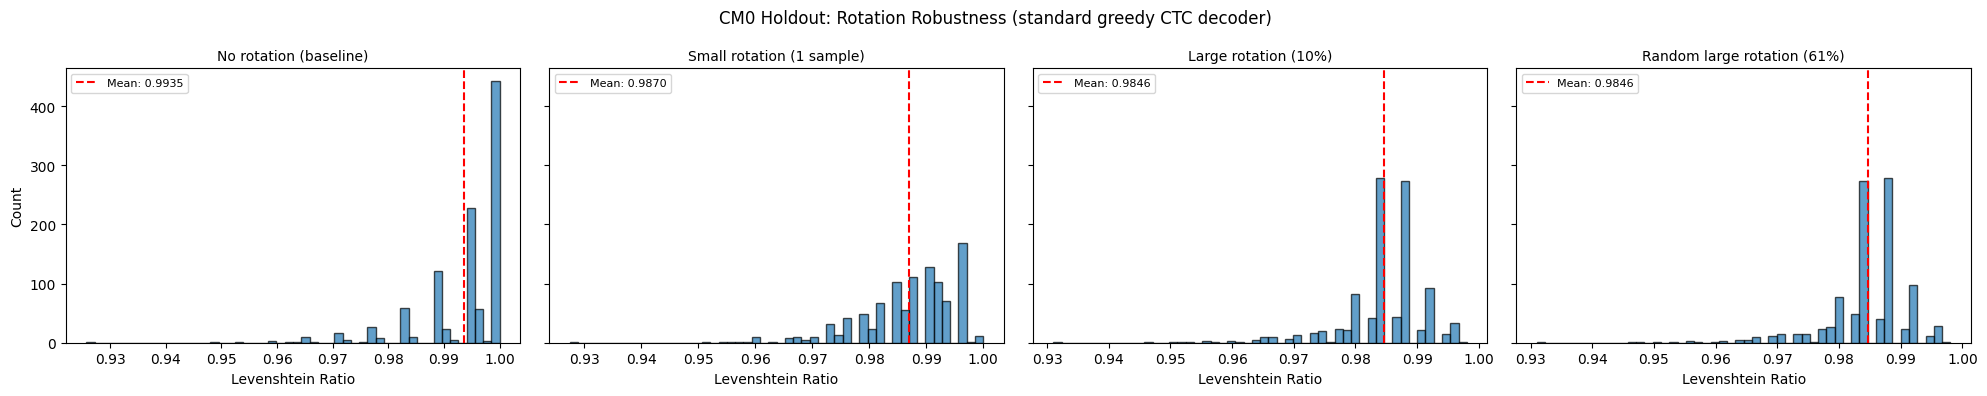

In [27]:
# Rotation robustness test as in the paper (Section 4):
#   - Rotate input traces by a fixed offset
#   - Predict on rotated traces
#   - Reverse-rotate prediction maps
#   - Decode with the short-burst-suppressed CTC decoder
#
# Test conditions from the paper:
#   1. Small rotation:  1 sample
#   2. Large rotation:  10% of trace length
#   3. Random large rotation: 61% of trace length (random seed for reproducibility)

trace_length = X_holdout.shape[1]  # 1600

rotation_configs = [
    ("No rotation (baseline)",    0),
    ("Small rotation (1 sample)", 1),
    ("Large rotation (10%)",      int(0.10 * trace_length)),  # 160
    ("Random large rotation (61%)", int(0.61 * trace_length)),  # 976
]

print(f"Trace length: {trace_length}")
print(f"Rotation offsets: {[(name, r) for name, r in rotation_configs]}")
print()

results = {}

for name, rotation in rotation_configs:
    print("=" * 70)
    print(f"  {name}  (offset = {rotation} samples)")
    print("=" * 70)
    
    # Step 1: Rotate input traces
    X_rotated = np.roll(X_holdout, rotation, axis=1)
    
    # Step 2: Predict
    X_eval = X_rotated if len(X_rotated.shape) == 3 else X_rotated[..., np.newaxis]
    Z_rotated = unet.predict(X_eval, batch_size=32, verbose=0)
    
    # Step 3: Reverse-rotate prediction maps
    Z_unrotated = np.roll(Z_rotated, -rotation, axis=1)
    
    # Step 4: Standard greedy CTC decode
    decoded_raw = K.ctc_decode(Z_unrotated,
                               input_length=np.ones(Z_unrotated.shape[0]) * trace_length,
                               greedy=True)[0][0].numpy()
    decoded_raw = decoded_raw[:, 0:num_features]
    
    # Step 5: Compute Levenshtein ratios
    ratios = []
    for i in range(len(decoded_raw)):
        pred_str = binary_array_to_string(decoded_raw[i])
        true_str = binary_array_to_string(Y_holdout[i])
        ratios.append(Levenshtein.ratio(pred_str, true_str))
    ratios = np.array(ratios)
    
    results[name] = ratios
    
    print(f"  Mean Levenshtein ratio: {np.mean(ratios):.4f}")
    print(f"  Std:  {np.std(ratios):.4f}")
    print(f"  Min:  {np.min(ratios):.4f}   Max: {np.max(ratios):.4f}")
    print(f"  Perfect (ratio=1.0): {100*np.mean(ratios==1.0):.2f}%")
    print()

# Summary table
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(f"{'Condition':<35s} {'Mean':>8s} {'Std':>8s} {'Min':>8s} {'Max':>8s}")
print("-" * 70)
for name, ratios in results.items():
    print(f"{name:<35s} {np.mean(ratios):>8.4f} {np.std(ratios):>8.4f} "
          f"{np.min(ratios):>8.4f} {np.max(ratios):>8.4f}")

# Histograms
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4), sharey=True)
for ax, (name, ratios) in zip(axes, results.items()):
    ax.hist(ratios, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(ratios), color='r', linestyle='--', linewidth=1.5,
               label=f'Mean: {np.mean(ratios):.4f}')
    ax.set_xlabel('Levenshtein Ratio')
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Count')
plt.suptitle('CM0 Holdout: Rotation Robustness (standard greedy CTC decoder)', fontsize=12)
plt.tight_layout()
plt.show()

CM3 raw shape: (8192, 20000)


100%|██████████| 8192/8192 [00:01<00:00, 5882.95it/s]


CM3 resampled shape: (8192, 17500)


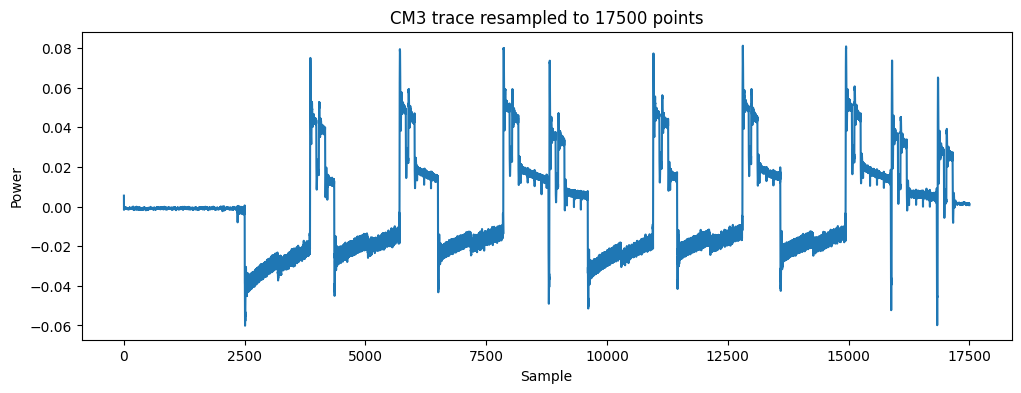

In [ ]:
# ============================================================================
# Cross-implementation transfer to CM3
# ============================================================================
# We test the CM0-trained U-Net on CM3 traces, following the same approach as
# in ctc_scaaml_data_test_feb_2026.ipynb (which used a CM1-trained model).
#
# CM0 at 1600 pts uses the same 1000x compression factor as CM1 at 5000 pts,
# so CM3 traces should be resampled to 17500 points (17.5M / 1000 = 17500).

from itertools import permutations
from tqdm import tqdm

# Load CM3 data
data_cm3 = np.load('../data/cm3_test/cm3_data.npz')
X_cm3 = data_cm3['X']
print(f"CM3 raw shape: {X_cm3.shape}")

# Resample to match CM0 resolution ratio
resample_size = 17500
X_cm3_resample = resize_data(X_cm3, resample_size)
print(f"CM3 resampled shape: {X_cm3_resample.shape}")

# Visualise overlay of CM0 holdout trace and CM3 resampled trace
plt.figure(figsize=(12, 4))
plt.plot(X_cm3_resample[0])
plt.title('CM3 trace resampled to 17500 points')
plt.xlabel('Sample')
plt.ylabel('Power')
plt.show()

In [84]:
# The CM0 U-net has never seen the spiky regions between scalar multiplications
# So we cut them out for the CM3 transfer test
# We manually pick fixed cut points by looking at the CM3 trace plotted above
# Each region is supposed to be 1600 points, so we just eyeball where they start

cut_points = [2300, 4100, 6200, 9300, 11200, 13500]

# Build the cut CM3 traces
X_cm3_cut = [X_cm3_resample[:, i:i+1600] for i in cut_points]

In [85]:
# Predict each cut region with the CM0 U-Net and greedy-CTC decode
# Each region is (8192, 1600), matching the model's input size exactly.

from itertools import permutations
from tqdm import tqdm

Z_cuts = []       # raw softmax predictions per region
dec_cuts = []     # greedy CTC decoded bit arrays per region

for region_idx, X_region in enumerate(X_cm3_cut):
    X_eval = X_region if len(X_region.shape) == 3 else X_region[..., np.newaxis]
    
    # Predict
    Z = unet.predict(X_eval, batch_size=32, verbose=0)
    Z_cuts.append(Z)
    
    # Greedy CTC decode
    decoded_raw = K.ctc_decode(Z,
                               input_length=np.ones(Z.shape[0]) * seq_length,
                               greedy=True)[0][0].numpy()
    
    # Per-trace: strip -1 padding, keep last 128 bits, prepend 128 zeros -> 256-bit vector
    target_bits = 128
    batch_decoded = np.zeros((decoded_raw.shape[0], num_features), dtype=np.int32)
    for j in range(decoded_raw.shape[0]):
        row = decoded_raw[j]
        row = row[row != -1]  # strip -1 padding
        if len(row) >= target_bits:
            tail = row[-target_bits:]
        else:
            tail = row
        # Place tail at the end of a 256-bit zero-padded vector
        batch_decoded[j, num_features - len(tail):] = tail
    dec_cuts.append(batch_decoded)
    
    # Diagnostics
    lengths = np.sum(decoded_raw != -1, axis=1)
    print(f"Region {region_idx} (cut @ {cut_points[region_idx]}): "
          f"decoded length mean={np.mean(lengths):.1f}, "
          f"min={np.min(lengths)}, max={np.max(lengths)}")

print(f"\nDecoded {len(dec_cuts)} regions, each shape {dec_cuts[0].shape}")

Region 0 (cut @ 2300): decoded length mean=237.2, min=203, max=252
Region 1 (cut @ 4100): decoded length mean=182.4, min=143, max=228
Region 2 (cut @ 6200): decoded length mean=175.5, min=91, max=291
Region 3 (cut @ 9300): decoded length mean=242.5, min=190, max=274
Region 4 (cut @ 11200): decoded length mean=152.8, min=105, max=175
Region 5 (cut @ 13500): decoded length mean=157.2, min=116, max=278

Decoded 6 regions, each shape (8192, 256)


/tmp/ipykernel_134626/3822362189.py:36: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  print(f"\n{num_shares} key shares, {num_shares} decoded regions -> testing {np.math.factorial(num_shares)} permutations")


CM3 Key Shares (padded to 256 bits with leading zeros):
  km2a      : 256 bits (already 256 bits)
  rem2a     : 256 bits (already 256 bits)
  r2a       : 128 bits -> 256 bits (prepended 128 zeros)
  km2b      : 256 bits (already 256 bits)
  rem2b     : 256 bits (already 256 bits)
  r2b       : 128 bits -> 256 bits (prepended 128 zeros)

6 key shares, 6 decoded regions -> testing 720 permutations

BEST PERMUTATION (reference trace 0)
Mean similarity across 6 regions: 98.3%

  Region -> Key share mapping:
    Region 0 (cut @  2300) -> km2a
    Region 1 (cut @  4100) -> rem2a
    Region 2 (cut @  6200) -> r2a
    Region 3 (cut @  9300) -> km2b
    Region 4 (cut @ 11200) -> rem2b
    Region 5 (cut @ 13500) -> r2b

EVALUATING BEST PERMUTATION ON ALL 8192 TRACES


100%|██████████| 8192/8192 [00:02<00:00, 3009.12it/s]



  Region  Key share     Mean%      Std%      Min%      Max%
-------------------------------------------------------
       0      km2a     99.17      0.41      95.7     100.0
       1     rem2a     99.30      0.43      87.1     100.0
       2       r2a     97.34      0.70      80.5      99.6
       3      km2b     98.18      0.78      87.5     100.0
       4     rem2b     99.16      0.60      85.9     100.0
       5       r2b     99.16      0.51      86.7     100.0

 Overall               98.72      0.33      88.7      99.6


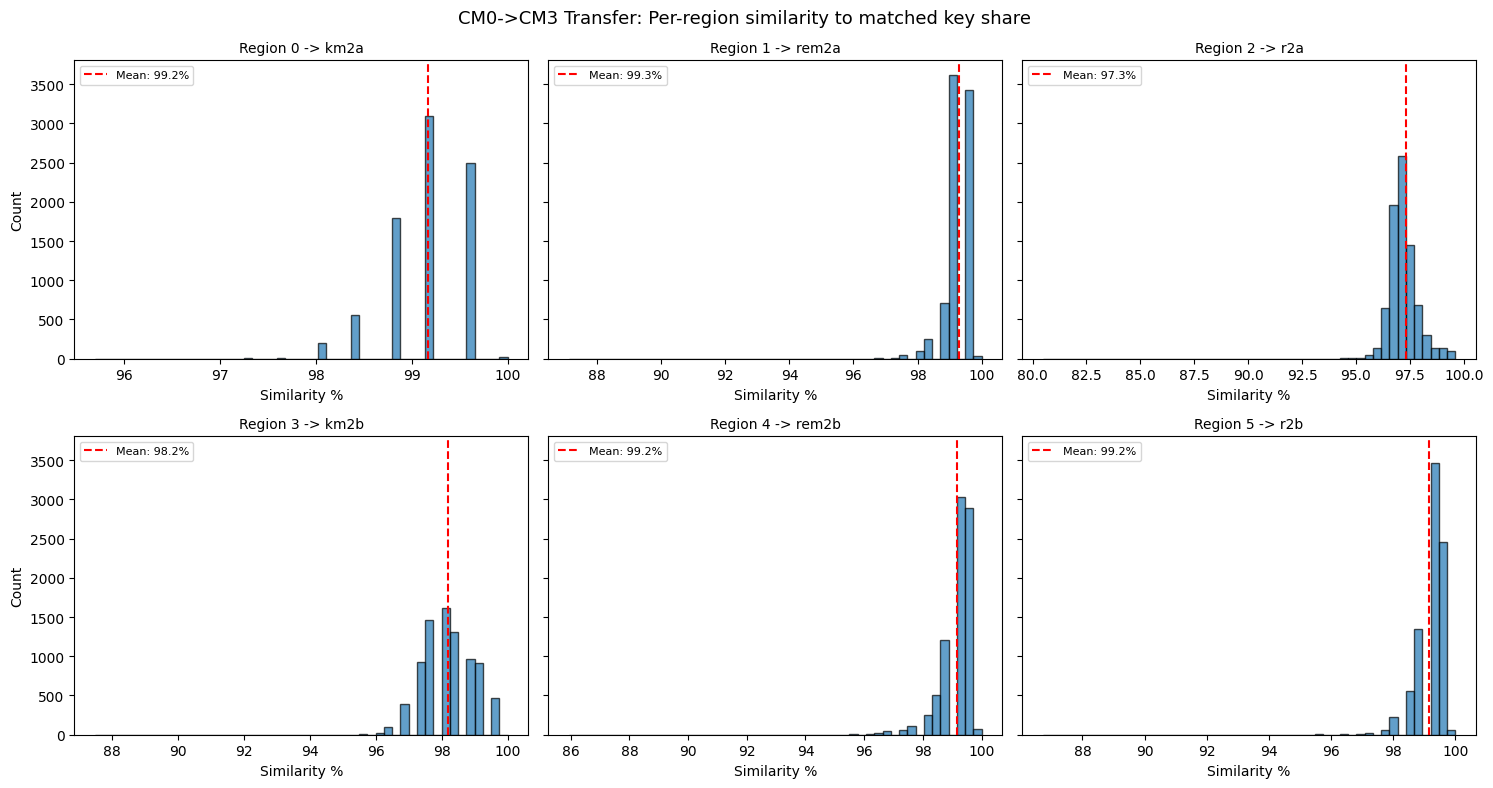

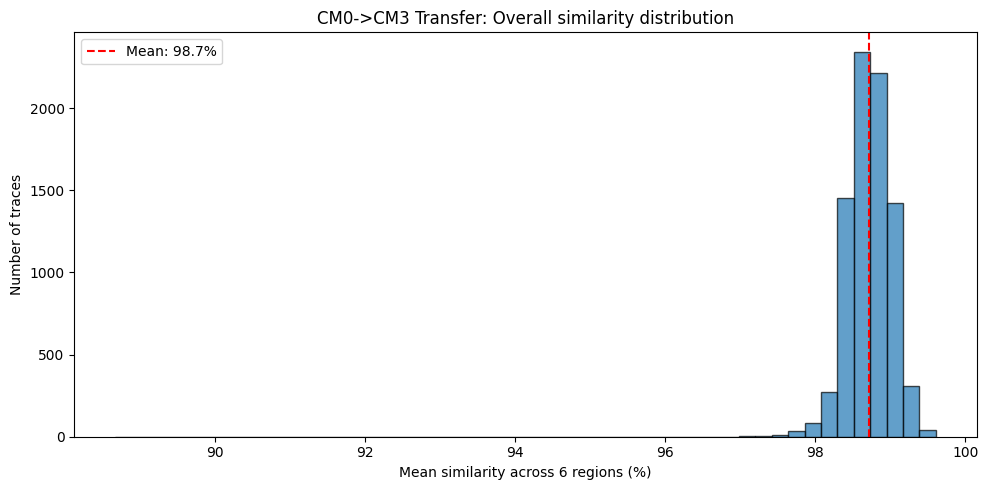

In [90]:
# Load CM3 key shares and find the best permutation mapping
# (following the approach from ctc_scaaml_data_test_feb_2026.ipynb cell 29)

km2a_bits  = data_cm3['km2a_bits']
rem2a_bits = data_cm3['rem2a_bits']
r2a_bits   = data_cm3['r2a_bits']
km2b_bits  = data_cm3['km2b_bits']
rem2b_bits = data_cm3['rem2b_bits']
r2b_bits   = data_cm3['r2b_bits']

key_shares_raw = {
    'km2a':  km2a_bits,
    'rem2a': rem2a_bits,
    'r2a':   r2a_bits,
    'km2b':  km2b_bits,
    'rem2b': rem2b_bits,
    'r2b':   r2b_bits,
}

# Pad all key shares to 256 bits (leading zeros), matching the hardware
segment_size = 256
key_shares_dict = {}

print("CM3 Key Shares (padded to 256 bits with leading zeros):")
for name, shares in key_shares_raw.items():
    if shares.shape[1] < segment_size:
        padding = segment_size - shares.shape[1]
        key_shares_dict[name] = np.pad(shares, ((0, 0), (padding, 0)), 'constant')
        print(f"  {name:10s}: {shares.shape[1]:3d} bits -> {segment_size} bits (prepended {padding:3d} zeros)")
    else:
        key_shares_dict[name] = shares
        print(f"  {name:10s}: {shares.shape[1]:3d} bits (already 256 bits)")

key_share_names = list(key_shares_dict.keys())
num_shares = len(key_share_names)
print(f"\n{num_shares} key shares, {num_shares} decoded regions -> testing {np.math.factorial(num_shares)} permutations")

# ---- Find best permutation on a reference trace ----
reference_idx = 0

# For each permutation, compute the mean similarity ratio across all 6 region-share pairs
import math

best_similarity = 0
best_permutation = None

for perm in permutations(range(num_shares)):
    total_ratio = 0
    for region_pos, share_idx in enumerate(perm):
        pred_str = binary_array_to_string(dec_cuts[region_pos][reference_idx])
        gt_str = binary_array_to_string(key_shares_dict[key_share_names[share_idx]][reference_idx])
        total_ratio += 100 * Levenshtein.ratio(pred_str, gt_str)
    mean_ratio = total_ratio / num_shares
    
    if mean_ratio > best_similarity:
        best_similarity = mean_ratio
        best_permutation = perm

print(f"\n{'='*60}")
print(f"BEST PERMUTATION (reference trace {reference_idx})")
print(f"{'='*60}")
print(f"Mean similarity across 6 regions: {best_similarity:.1f}%\n")
print(f"  Region -> Key share mapping:")
for pos, share_idx in enumerate(best_permutation):
    print(f"    Region {pos} (cut @ {cut_points[pos]:5d}) -> {key_share_names[share_idx]}")

# ---- Apply best permutation to ALL traces ----
print(f"\n{'='*60}")
print(f"EVALUATING BEST PERMUTATION ON ALL {X_cm3_cut[0].shape[0]} TRACES")
print(f"{'='*60}")

per_region_ratios = [[] for _ in range(num_shares)]
overall_ratios = []

for trace_idx in tqdm(range(X_cm3_cut[0].shape[0])):
    trace_total = 0
    for region_pos, share_idx in enumerate(best_permutation):
        pred_str = binary_array_to_string(dec_cuts[region_pos][trace_idx])
        gt_str = binary_array_to_string(key_shares_dict[key_share_names[share_idx]][trace_idx])
        ratio = 100 * Levenshtein.ratio(pred_str, gt_str)
        per_region_ratios[region_pos].append(ratio)
        trace_total += ratio
    overall_ratios.append(trace_total / num_shares)

overall_ratios = np.array(overall_ratios)
per_region_ratios = [np.array(r) for r in per_region_ratios]

# ---- Per-region results ----
print(f"\n{'Region':>8s}  {'Key share':>8s}  {'Mean%':>8s}  {'Std%':>8s}  {'Min%':>8s}  {'Max%':>8s}")
print("-" * 55)
for pos in range(num_shares):
    share_name = key_share_names[best_permutation[pos]]
    arr = per_region_ratios[pos]
    print(f"{pos:>8d}  {share_name:>8s}  {np.mean(arr):>8.2f}  {np.std(arr):>8.2f}  "
          f"{np.min(arr):>8.1f}  {np.max(arr):>8.1f}")

print(f"\n{'Overall':>8s}  {'':>8s}  {np.mean(overall_ratios):>8.2f}  {np.std(overall_ratios):>8.2f}  "
      f"{np.min(overall_ratios):>8.1f}  {np.max(overall_ratios):>8.1f}")

# ---- Plot ----
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for pos, ax in enumerate(axes.flat):
    share_name = key_share_names[best_permutation[pos]]
    arr = per_region_ratios[pos]
    ax.hist(arr, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(arr), color='r', linestyle='--', linewidth=1.5,
               label=f'Mean: {np.mean(arr):.1f}%')
    ax.set_title(f'Region {pos} -> {share_name}', fontsize=10)
    ax.set_xlabel('Similarity %')
    ax.legend(fontsize=8)
axes[0, 0].set_ylabel('Count')
axes[1, 0].set_ylabel('Count')
plt.suptitle('CM0->CM3 Transfer: Per-region similarity to matched key share', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Overall histogram ----
plt.figure(figsize=(10, 5))
plt.hist(overall_ratios, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(overall_ratios), color='r', linestyle='--', linewidth=1.5,
            label=f'Mean: {np.mean(overall_ratios):.1f}%')
plt.xlabel('Mean similarity across 6 regions (%)')
plt.ylabel('Number of traces')
plt.title('CM0->CM3 Transfer: Overall similarity distribution')
plt.legend()
plt.tight_layout()
plt.show()

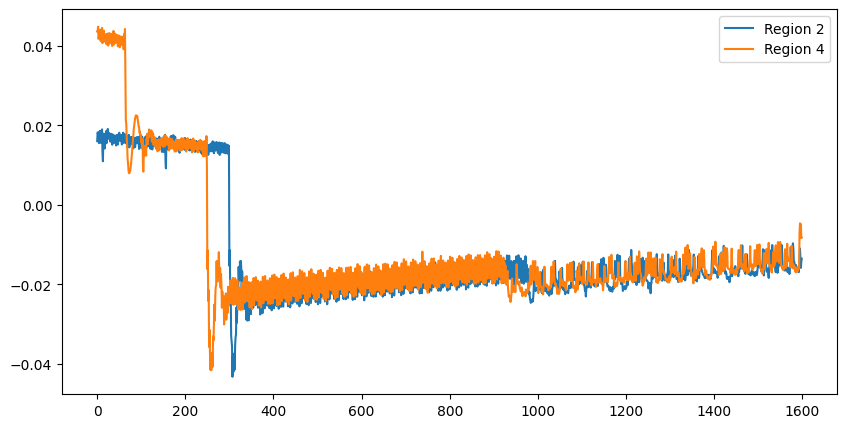

In [92]:
# plot examples of regions two and four
plt.figure(figsize=(10, 5))
plt.plot(X_cm3_cut[2][0])
plt.plot(X_cm3_cut[4][0])
plt.legend(['Region 2', 'Region 4'])
plt.show()

In [93]:
# For each region, print one random example: the 128-bit tail of the prediction
# alongside the corresponding ground-truth key share (full 256 bits).

np.random.seed(7)

for pos, share_idx in enumerate(best_permutation):
    trace_idx = np.random.randint(0, X_cm3_cut[0].shape[0])
    share_name = key_share_names[share_idx]
    
    pred_256 = dec_cuts[pos][trace_idx]          # 256 bits: 128 zeros + 128-bit tail
    gt_256   = key_shares_dict[share_name][trace_idx]  # 256-bit ground truth
    
    pred_str = binary_array_to_string(pred_256)
    gt_str   = binary_array_to_string(gt_256)
    
    ratio = Levenshtein.ratio(pred_str, gt_str)
    
    print(f"Region {pos} -> {share_name}  (trace {trace_idx}, similarity ratio {ratio}%)")
    print(f"  GT:   {gt_str[:32]}...{gt_str[128:160]}...{gt_str[-32:]}")
    print(f"  Pred: {pred_str[:32]}...{pred_str[128:160]}...{pred_str[-32:]}")
    # Show just the last 128 bits side by side for clarity
    print(f"  --- last 128 bits ---")
    print(f"  GT:   {gt_str[128:]}")
    print(f"  Pred: {pred_str[128:]}")
    match = sum(a == b for a, b in zip(gt_str[128:], pred_str[128:]))
    print(f"  Bit accuracy (last 128): {match}/128 = {100*match/128:.1f}%")
    print()

Region 0 -> km2a  (trace 4271, similarity ratio 0.9921875%)
  GT:   00000000000000000000000000000000...11111111110000110110110110001011...11100110000100010100101000011101
  Pred: 00000000000000000000000000000000...11111111100001101101101100010110...11001100001000101001010000111011
  --- last 128 bits ---
  GT:   11111111110000110110110110001011001111001000000010110110110011011011010010110000000001101110001111100110000100010100101000011101
  Pred: 11111111100001101101101100010110011110010000000101101101100110110110100101100000000011011100011111001100001000101001010000111011
  Bit accuracy (last 128): 70/128 = 54.7%

Region 1 -> rem2a  (trace 1220, similarity ratio 0.9921875%)
  GT:   00000000000000000000000000000000...00001100101101111000111101001010...10100111001111001001111101001010
  Pred: 00000000000000000000000000000000...01000010010110111100011110100101...11010011100111100100111110100101
  --- last 128 bits ---
  GT:   00001100101101111000111101001010000101101001111001000101101100